In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, spearmanr
from sklearn.preprocessing import StandardScaler
import os

PROCESSED_DIR = r"C:\Users\HP\Desktop\thesis_preprocessing\data\processed"
OUTPUT_DIR = r"C:\Users\HP\Desktop\thesis_preprocessing\outputs"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
LOG_FILE = os.path.join(OUTPUT_DIR, "Descriptive_Analytics_Log.txt")
os.makedirs(FIGURES_DIR, exist_ok=True)

with open(LOG_FILE, "w", encoding="utf-8") as f:
    f.write("=== THESIS DESCRIPTIVE ANALYTICS LOG ===\n\n")

def log_result(text):
    print(text)
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(text + "\n")

# Load V2 datasets (Now making sure adak_ss is loaded!)
df_orig = pd.read_csv(os.path.join(PROCESSED_DIR, "01_Original_12k_V2_scored.csv")).dropna(subset=['codebert_score', 'adak_index', 'adak_ss'])
df_dist_a = pd.read_csv(os.path.join(PROCESSED_DIR, "02_Distractor_A_Swapped_12k_V2_scored.csv")).dropna(subset=['codebert_score', 'adak_index', 'adak_ss'])
df_dist_b = pd.read_csv(os.path.join(PROCESSED_DIR, "03_Distractor_B_Shuffled_12k_V2_scored.csv")).dropna(subset=['codebert_score', 'adak_index', 'adak_ss'])

# Ensure word/token counts exist
token_col = 'code_token_length' if 'code_token_length' in df_orig.columns else 'token_count'
for df in [df_orig, df_dist_a, df_dist_b]:
    if 'comment_word_count' not in df.columns:
        df['comment_word_count'] = df['comment'].apply(lambda x: len(str(x).split()))
    if 'code_token_length' not in df.columns:
        df['code_token_length'] = df[token_col]

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12})
log_result("Setup Complete. Data loaded and preprocessed.")

Setup Complete. Data loaded and preprocessed.


In [2]:
log_result(f"\n{'='*50}\n2. DEEP STATISTICAL PROFILING\n{'='*50}")

# ADDED adak_ss TO THE LIST
variables = ['adak_index', 'adak_ss', 'codebert_score', 'mcv', 'sfv']

def get_detailed_stats(dataframe, columns):
    summary = dataframe[columns].describe().T
    summary['mode'] = dataframe[columns].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    summary['skewness'] = dataframe[columns].skew()
    summary['kurtosis'] = dataframe[columns].apply(kurtosis)
    return summary.round(4)

global_stats = get_detailed_stats(df_orig, variables)
log_result("GLOBAL STATISTICS (All Languages Combined):")
log_result(global_stats[['mean', '50%', 'mode', 'skewness', 'kurtosis']].to_string())


2. DEEP STATISTICAL PROFILING
GLOBAL STATISTICS (All Languages Combined):
                   mean      50%     mode  skewness  kurtosis
adak_index     -73.5733 -87.3016 -88.4058   11.9735  285.1411
adak_ss        -77.4123 -88.2823 -89.3044   15.0761  497.7170
codebert_score   0.9737   0.9998   0.9998   -5.5064   31.8254
mcv              3.5603   2.4000   0.8000   10.9372  249.6134
sfv             22.3506  15.0000   6.9000    2.4506    7.3131



3. ML DATA NORMALIZATION ANALYSIS


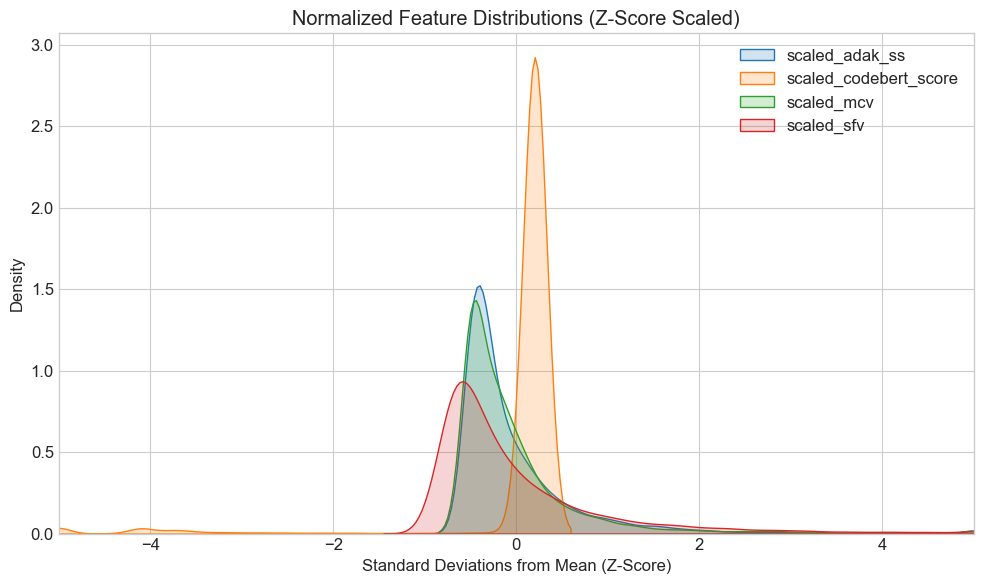

Normalization complete. Distribution graph saved to demonstrate feature alignment for ML.


In [3]:
log_result(f"\n{'='*50}\n3. ML DATA NORMALIZATION ANALYSIS\n{'='*50}")

scaler = StandardScaler()
# Replacing 'adak_index' with 'adak_ss' to show the improved metric
features_to_scale = ['adak_ss', 'codebert_score', 'mcv', 'sfv']

scaled_data = scaler.fit_transform(df_orig[features_to_scale])
df_scaled = pd.DataFrame(scaled_data, columns=[f"scaled_{f}" for f in features_to_scale])

plt.figure(figsize=(10, 6))
for col in df_scaled.columns:
    sns.kdeplot(df_scaled[col].clip(-5, 5), label=col, fill=True, alpha=0.2)

plt.title('Normalized Feature Distributions (Z-Score Scaled)')
plt.xlabel('Standard Deviations from Mean (Z-Score)')
plt.ylabel('Density')
plt.xlim(-5, 5)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "EDA_Normalized_Distributions.png"), dpi=300, bbox_inches='tight')
plt.show()

log_result("Normalization complete. Distribution graph saved to demonstrate feature alignment for ML.")


4. CODE COMPLEXITY (SFV) DISTRIBUTION ANALYSIS


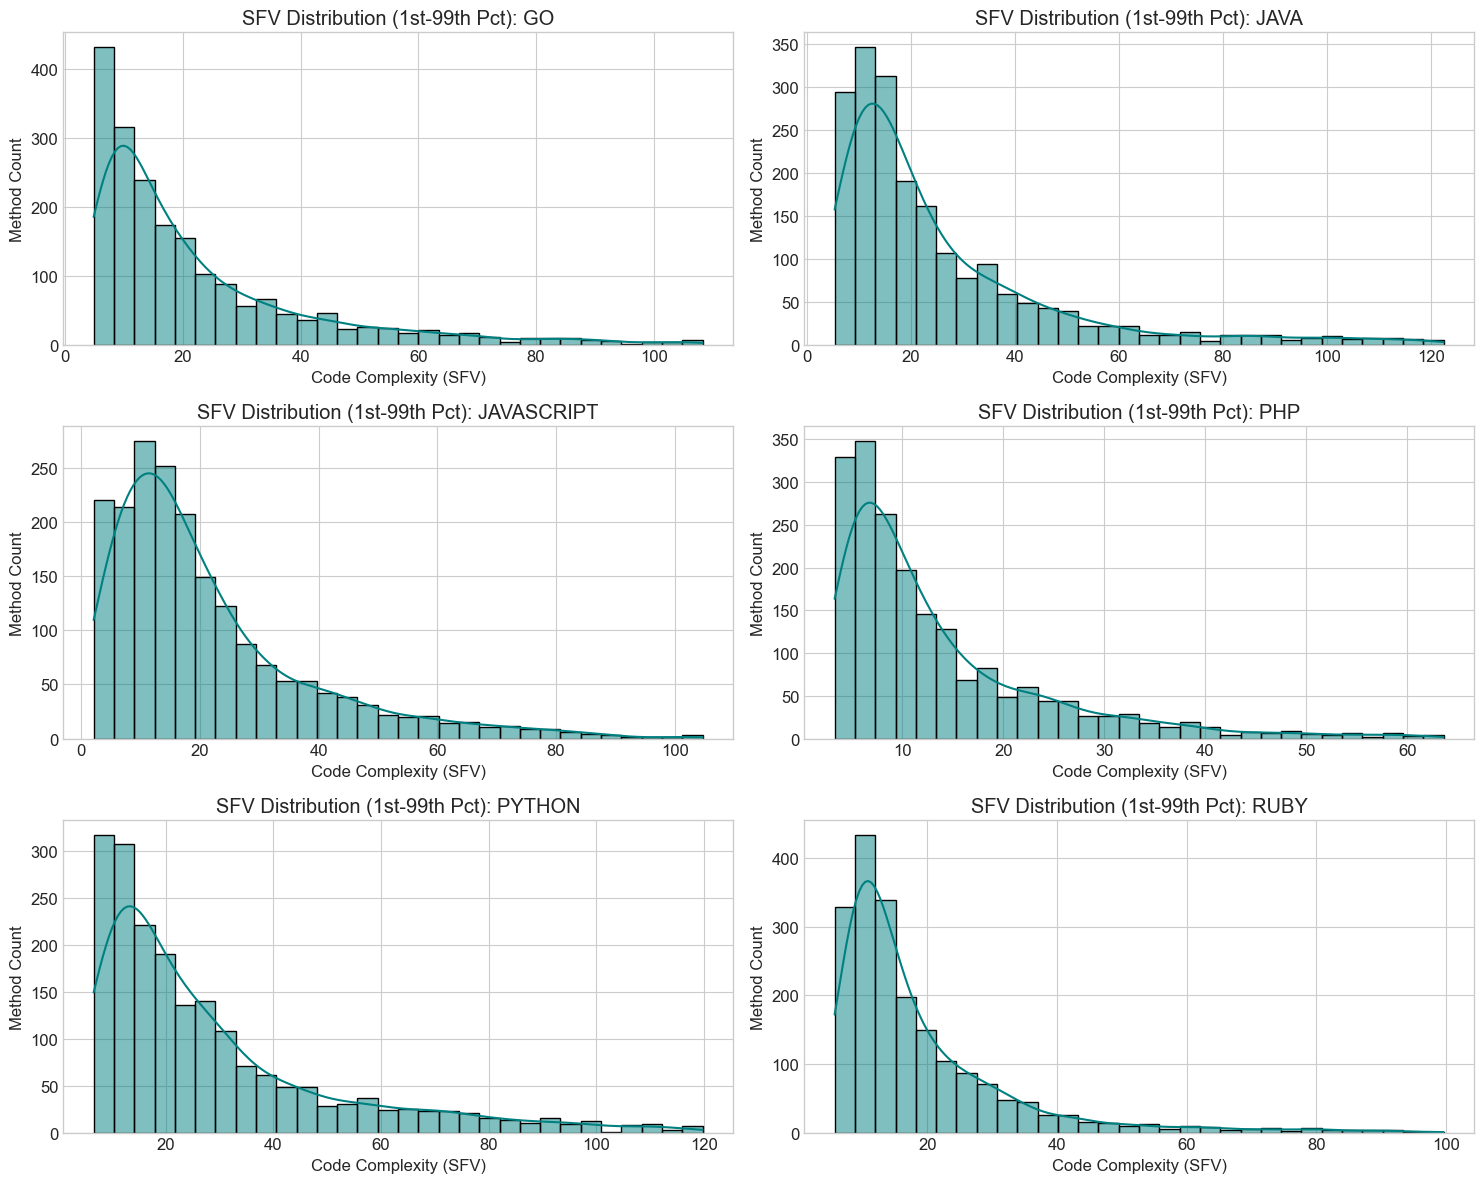

In [4]:
log_result(f"\n{'='*50}\n4. CODE COMPLEXITY (SFV) DISTRIBUTION ANALYSIS\n{'='*50}")

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, lang in enumerate(df_orig['language'].unique()):
    lang_data = df_orig[df_orig['language'] == lang]
    
    lower_limit = lang_data['sfv'].quantile(0.01)
    upper_limit = lang_data['sfv'].quantile(0.99)
    clean_plot_data = lang_data[(lang_data['sfv'] >= lower_limit) & (lang_data['sfv'] <= upper_limit)]

    sns.histplot(clean_plot_data['sfv'], kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'SFV Distribution (1st-99th Pct): {lang.upper()}')
    axes[i].set_xlabel('Code Complexity (SFV)')
    axes[i].set_ylabel('Method Count')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "EDA_SFV_Per_Language.png"), dpi=300, bbox_inches='tight')
plt.show()


6. SEMANTIC GROUND TRUTH VALIDATION


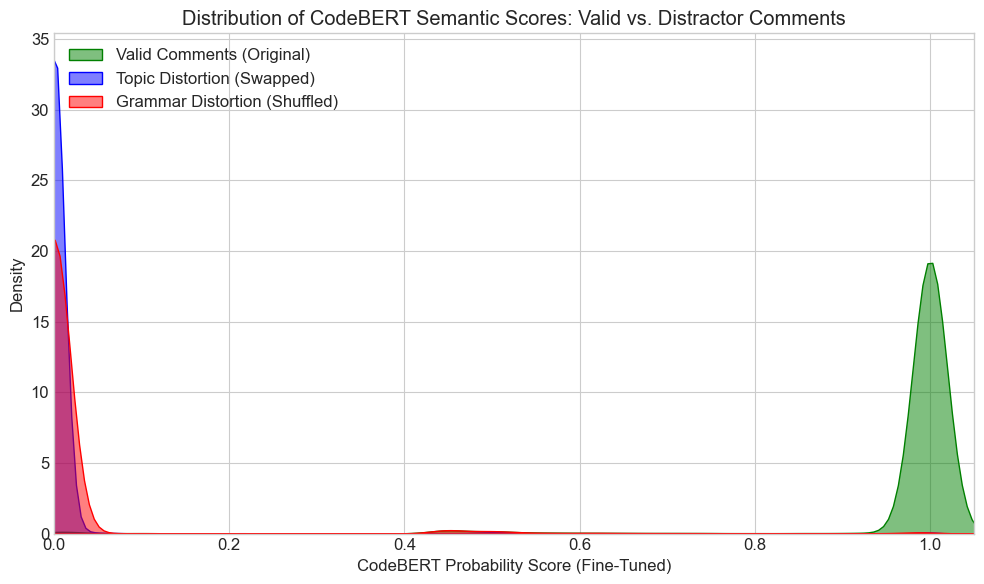


Descriptive Analytics successfully completed.


In [5]:
log_result(f"\n{'='*50}\n6. SEMANTIC GROUND TRUTH VALIDATION\n{'='*50}")

plt.figure(figsize=(10, 6))
sns.kdeplot(df_orig['codebert_score'], fill=True, color='green', label='Valid Comments (Original)', alpha=0.5)
sns.kdeplot(df_dist_a['codebert_score'], fill=True, color='blue', label='Topic Distortion (Swapped)', alpha=0.5)
sns.kdeplot(df_dist_b['codebert_score'], fill=True, color='red', label='Grammar Distortion (Shuffled)', alpha=0.5)

plt.title('Distribution of CodeBERT Semantic Scores: Valid vs. Distractor Comments')
plt.xlabel('CodeBERT Probability Score (Fine-Tuned)')
plt.ylabel('Density')
plt.legend(loc='upper left')

# Note: Range changed to 0.0 - 1.0 because CodeBERT is now fine-tuned!
plt.xlim(0.0, 1.05) 
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "EDA_CodeBERT_Distributions.png"), dpi=300, bbox_inches='tight')
plt.show()
log_result("\nDescriptive Analytics successfully completed.")

In [6]:
# Columns we want to show in Appendix E
cols_to_show = ['language', 'mcv', 'sfv', 'adak_index', 'adak_ss', 'codebert_score', 'label']

print("=== E.1 Original Dataset (Valid Class 1) ===")
print(df_orig[cols_to_show].head(1).to_string(index=False))
print("\n")

print("=== E.2 Distractor A Dataset (Topic Swapped Class 0) ===")
print(df_dist_a[cols_to_show].head(1).to_string(index=False))
print("\n")

print("=== E.3 Distractor B Dataset (Grammar Shuffled Class 2) ===")
print(df_dist_b[cols_to_show].head(1).to_string(index=False))

=== E.1 Original Dataset (Valid Class 1) ===
language  mcv  sfv  adak_index    adak_ss  codebert_score  label
      go  8.8 18.6  -52.688172 -53.494715        0.999822      1


=== E.2 Distractor A Dataset (Topic Swapped Class 0) ===
language  mcv  sfv  adak_index    adak_ss  codebert_score  label
      go  5.6 18.6  -69.892473 -70.405728        0.000101      0


=== E.3 Distractor B Dataset (Grammar Shuffled Class 2) ===
language  mcv  sfv  adak_index    adak_ss  codebert_score  label
      go  0.8 18.6  -95.698925 -95.772247        0.000061      0
